# Car Plate Recognition

# Load Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils
import easyocr
import os
os.chdir(r"C:\Users\DT1\Desktop\proj-python\Images_Vision")

Load image

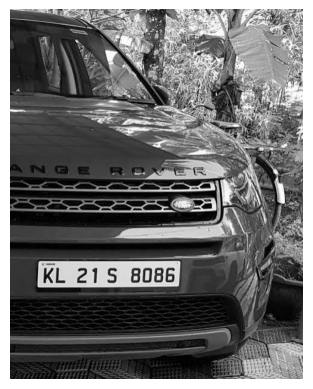

In [3]:
# img=cv2.imread("car_plate1.jpg")
img=cv2.imread("car_plate2.jpg")
# img=cv2.imread("car_plate3.jpg")
# img=cv2.imread("car_plate4.jpg")
# img=cv2.imread("car_plate5.jpg")

gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Using Filter to reduce noise

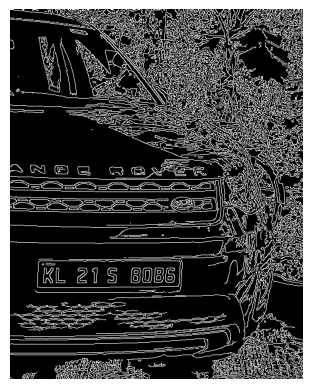

In [4]:
bfilter=cv2.bilateralFilter(gray,11,17,17)
edged=cv2.Canny(bfilter,30,200)
plt.imshow(cv2.cvtColor(edged,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
#

# Using Contours_Grab

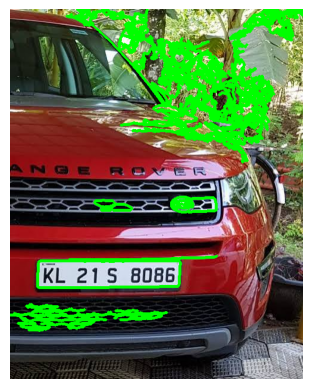

In [5]:
points=cv2.findContours(edged,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
contours=imutils.grab_contours(points)
contours=sorted(contours,key=cv2.contourArea,reverse=True)[:10]
cv2.drawContours(img,contours,-1,(0,255,0),3)
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Determine Location

In [6]:
location=None
for con in contours:
  
  epsilon=0.01*cv2.arcLength(con,True)
  approx=cv2.approxPolyDP(con,epsilon,True)

  if len(approx)==4:
    (x,y,w,h)=cv2.boundingRect(approx)
    if w > 100 and h > 30:
      aspect_ratio = w / float(h)
      if 2 < aspect_ratio < 6:

       location=approx
       break
print("Location:",location)

Location: [[[ 47 426]]

 [[283 422]]

 [[284 461]]

 [[ 48 467]]]


# Create Mask for Detection

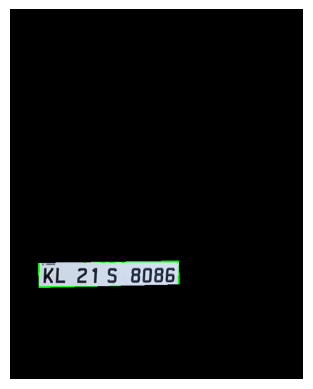

In [7]:
mask=np.zeros(gray.shape,np.uint8)
new_image=cv2.drawContours(mask,[location],-1,(255,255,255),-2)
new_image=cv2.bitwise_and(img,img,mask=mask)
plt.imshow(cv2.cvtColor(new_image,cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# projection Mask on Original image

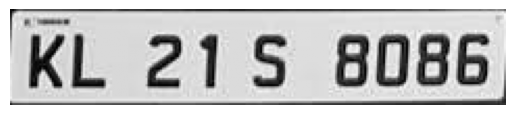

In [8]:
(x,y)=np.where(mask==255)
(x1,y1)=(np.min(x),np.min(y))
(x2,y2)=(np.max(x),np.max(y))
cropped_image=gray[x1:x2+1,y1:y2+1]
plt.imshow(cropped_image,cmap='gray')
plt.axis("off")
plt.show()

# Reading By OCR

In [9]:
reader=easyocr.Reader(['en'])
result=reader.readtext(cropped_image)
print("result",result)

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
c:\Users\DT1\Desktop\proj-python\.dlib\Lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(
c:\Users\DT1\Desktop\proj-python\.dlib\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


result [([[3, 7], [51, 7], [51, 45], [3, 45]], 'KL', 0.9985789355998865), ([[61, 7], [141, 7], [141, 45], [61, 45]], '215', 0.9931216583870043), ([[151, 7], [237, 7], [237, 43], [151, 43]], '8086', 0.9998555183410645)]


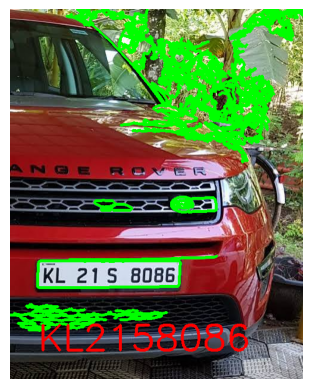

confidence:
0.9985789355998865
0.9931216583870043
0.9998555183410645


In [10]:
text=""
conf=[]
for t in result:
    text+=str(t[-2])
    conf.append(t[-1])
font=cv2.FONT_HERSHEY_SIMPLEX
res=cv2.putText(img,text=text,org=(approx[0][0][0],approx[1][0][1]+150),fontFace=font,fontScale=2,color=(0,0,255),thickness=4)
plt.imshow(cv2.cvtColor(res,cv2.COLOR_BGR2RGB)) 
plt.axis("off")
plt.show()
print("confidence:")
for x in conf:
    print(x)